# Add Ice Concentration to Profile Dataset

Adds an `ice_conc` variable (per-profile dimension) to a NetCDF profile file.  
Ice concentration (%) is retrieved by nearest-neighbour lookup in daily OSI SAF sea-ice concentration files.

| value | meaning |
|-------|---------|
| NaN | not set (ice file unavailable or profile outside ice grid) |
| 0 | ice free |
| >0 | ice present (concentration in %) |

## Configuration — edit here

In [17]:
# ── INPUT ──────────────────────────────────────────────────────────────────────
INPUT_FILE = (
    #"/home/nicolas/SACO/FRESH-CARE/Codes/WP2/buongiorno_to_pytorch_padding"
    #"../data_for_lstm/var_depths_data_for_LSTM_B3_bathy.nc"
    "../trained_models/wg_daily_strat_real_only_mcdo_val/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/mc_test_results.nc"
)

# ── OUTPUT ─────────────────────────────────────────────────────────────────────
OUTPUT_FILE = (
    #"/home/nicolas/SACO/FRESH-CARE/Codes/WP2/buongiorno_to_pytorch_padding"
    #"../data_for_lstm/var_depths_data_for_LSTM_B4_icemask.nc"
    "../trained_models/wg_daily_strat_real_only_mcdo_val/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/mc_test_results.nc"
)

# ── SEA-ICE DATA ───────────────────────────────────────────────────────────────
# Available years currently downloaded: 2011, 2012
# Directory structure: {ICE_DIR}/{YYYY}/{MM}/ice_conc_nh_polstere-100_multi_{YYYYMMDD}1200.nc
ICE_DIR = "/home/nicolas/SACO/FRESH-CARE/Data_satellite/sea_ice"

# ── PROFILE VARIABLE NAMES ─────────────────────────────────────────────────────
# Names of latitude, longitude and time variables in the profile file
LAT_VAR  = "LATITUDE"
LON_VAR  = "LONGITUDE"
TIME_VAR = "TIME"

## Imports and KD-tree construction

The ice-concentration files all share the same polar-stereographic grid, so we build the KD-tree once from a single file. Coordinates are converted to 3D Cartesian before indexing to handle the polar geometry correctly.

In [18]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.spatial import cKDTree
from pathlib import Path
from tqdm.notebook import tqdm


# ── Helper: lat/lon → unit-sphere Cartesian ────────────────────────────────────
def _latlon_to_xyz(lat_deg: np.ndarray, lon_deg: np.ndarray) -> np.ndarray:
    """Convert lat/lon (degrees) to 3-D Cartesian coordinates on the unit sphere."""
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.stack([x, y, z], axis=-1)


# ── Build KD-tree from the static ice-grid lat/lon ─────────────────────────────
# Any ice file will do; the grid is the same for all of them.
_sample_ice_file = next(Path(ICE_DIR).glob("????/??/ice_conc_nh_polstere-100_multi_*.nc"))
with xr.open_dataset(_sample_ice_file) as _ds_ice:
    _ice_lat = _ds_ice["lat"].values   # (yc, xc)  float32
    _ice_lon = _ds_ice["lon"].values   # (yc, xc)  float32

_ICE_NY, _ICE_NX = _ice_lat.shape
_ice_xyz_flat = _latlon_to_xyz(_ice_lat, _ice_lon).reshape(-1, 3)  # (yc*xc, 3)
ice_tree = cKDTree(_ice_xyz_flat)

print(f"KD-tree built: {_ICE_NY} × {_ICE_NX} = {_ice_xyz_flat.shape[0]:,} grid points  "
      f"(sample file: {_sample_ice_file.name})")


KD-tree built: 1120 × 760 = 851,200 grid points  (sample file: ice_conc_nh_polstere-100_multi_201505021200.nc)


## Process profiles — assign ice concentration

For each unique calendar day in the profile file:
1. Locate the corresponding daily ice-concentration file.
2. Query the KD-tree with the 3-D Cartesian coordinates of the profiles on that day.
3. Read `ice_conc` (%) at the nearest grid point and store it directly.

Profiles whose date has no matching ice file (or where the ice grid itself returns NaN) are left as **NaN**.

In [19]:
ds_prof = xr.open_dataset(INPUT_FILE).load()   # .load() reads all data into memory so the file can be safely overwritten
n_prof  = ds_prof.sizes["profile"]

prof_lat  = ds_prof[LAT_VAR].values                     # (profile,)
prof_lon  = ds_prof[LON_VAR].values                     # (profile,)
prof_time = pd.to_datetime(ds_prof[TIME_VAR].values)    # DatetimeIndex

# Pre-compute Cartesian coords for all profiles (used in tree queries below)
prof_xyz = _latlon_to_xyz(prof_lat, prof_lon)           # (profile, 3)

# Initialise ice_conc as NaN (not set)
ice_conc = np.full(n_prof, np.nan, dtype=np.float32)

# Unique calendar days present in the profile file
prof_dates = prof_time.normalize()                      # floor to midnight
unique_days = prof_dates.unique()                       # DatetimeIndex → iterates as Timestamp

n_set = n_missing = 0
print(f"Profiles: {n_prof:,}   |   Unique days: {len(unique_days)}")

for day in tqdm(unique_days, desc="Processing days", unit="day"):
    year  = day.year
    month = day.month
    dom   = day.day

    ice_file = (
        Path(ICE_DIR)
        / f"{year:04d}"
        / f"{month:02d}"
        / f"ice_conc_nh_polstere-100_multi_{year:04d}{month:02d}{dom:02d}1200.nc"
    )

    # Indices of profiles on this calendar day
    day_idx = np.where(prof_dates == day)[0]

    if not ice_file.exists():
        n_missing += len(day_idx)
        continue   # leave those profiles as NaN

    with xr.open_dataset(ice_file) as ds_ice:
        # ice_conc shape: (time=1, yc, xc) — xarray auto-decodes _FillValue → NaN
        conc = ds_ice["ice_conc"].values[0]              # (yc, xc)  float32

    # Nearest-neighbour lookup (Cartesian distance on unit sphere)
    _, nn_flat = ice_tree.query(prof_xyz[day_idx])       # flat indices into yc*xc
    yc_idx, xc_idx = np.unravel_index(nn_flat, (_ICE_NY, _ICE_NX))
    conc_vals = conc[yc_idx, xc_idx]                     # float32 per profile

    # Store concentration directly (NaN where ice grid itself is NaN)
    ice_conc[day_idx] = conc_vals
    n_set += len(day_idx)

n_nan = np.sum(np.isnan(ice_conc))
print(f"\nice_conc assigned for {n_set:,} profiles")
print(f"No ice file (→ NaN): {n_missing:,} profiles")
print(f"NaN from ice grid:   {n_nan - n_missing:,} profiles")
print(f"ice present (>0):    {np.sum(ice_conc > 0):,} profiles")
print(f"ice free (=0):       {np.sum(ice_conc == 0):,} profiles")


Profiles: 29,371   |   Unique days: 3978


Processing days:   0%|          | 0/3978 [00:00<?, ?day/s]


ice_conc assigned for 29,299 profiles
No ice file (→ NaN): 72 profiles
NaN from ice grid:   3,354 profiles
ice present (>0):    10,173 profiles
ice free (=0):       15,772 profiles


#### check the locations of unassigned profiles from ice grid

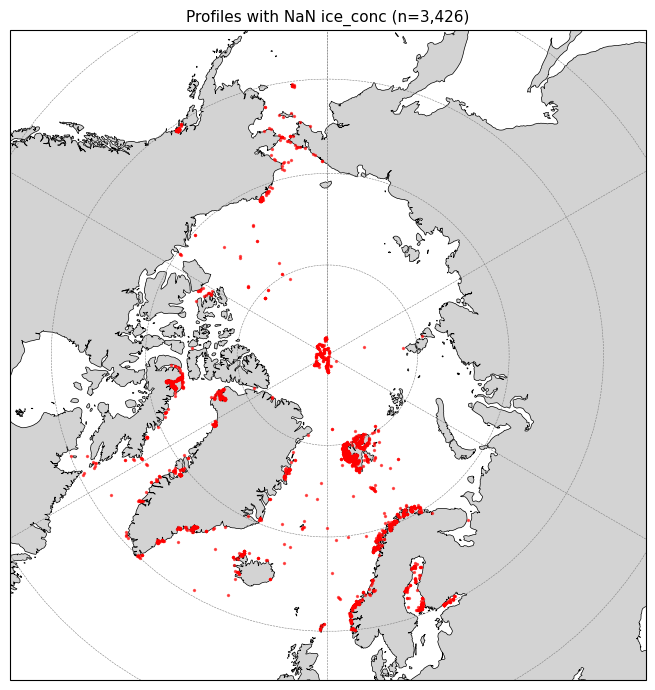

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

nan_mask = np.isnan(ice_conc)

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"projection": ccrs.NorthPolarStereo()},
)
ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
ax.gridlines(draw_labels=False, linewidth=0.4, linestyle="--", color="gray")

ax.scatter(
    prof_lon[nan_mask], prof_lat[nan_mask],
    s=2, color="red", alpha=0.6,
    transform=ccrs.PlateCarree(),
    zorder=3,
)
ax.set_title(f"Profiles with NaN ice_conc (n={nan_mask.sum():,})", fontsize=11)
plt.tight_layout()
plt.show()


## Save output

In [21]:
ice_conc_da = xr.DataArray(
    ice_conc,
    dims=["profile"],
    attrs={
        "long_name": "Sea-ice concentration (nearest-neighbour from OSI SAF daily product)",
        "units": "%",
        "valid_range": np.array([0.0, 100.0], dtype=np.float32),
        "source": "OSI SAF OSI-401 daily sea-ice concentration",
        "comment": (
            "NaN: not set (ice file unavailable or profile outside ice grid); "
            "0: ice free; >0: ice present (concentration in %)"
        ),
    },
)

ds_out = ds_prof.assign(ice_conc=ice_conc_da)

# Carry over existing encoding and add lossless compression
encoding = {}
for v in ds_out.data_vars:
    enc = {"zlib": True, "complevel": 4}
    if v == "ice_conc":
        enc["dtype"] = "float32"
    encoding[v] = enc

# Close the input dataset before writing — required when OUTPUT_FILE == INPUT_FILE
ds_prof.close()

ds_out.to_netcdf(OUTPUT_FILE, encoding=encoding)
print(f"Saved → {OUTPUT_FILE}")


Saved → ../trained_models/wg_daily_strat_real_only_mcdo_val/AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/mc_test_results.nc
